In [4]:
import nc_py_api
import os

## Config for connection

In [5]:
configuration = {
    'nextcloud_url': "https://laboppad.nl/",
    'nc_auth_user': os.getenv("NC_AUTH_USER"),
    'nc_auth_pass': os.getenv("NC_AUTH_PASS")
}

nc_py_api.options.NPA_NC_CERT = False

In [6]:
nc = nc_py_api.Nextcloud(**configuration)

## Upload a simple textfile

In [10]:
remote_path = "falnama-project/Uploadfolder/firstupload.txt"
local_path = "./firstupload.txt"
with open(local_path, 'br') as fp:
    nc.files.upload_stream(remote_path, fp)

## Download a simple textfile

In [9]:
remote_path = "falnama-project/Uploadfolder/firstupload.txt"
local_path = "./firstdownload"
with open(local_path, 'bw') as fp:
    nc.files.download2stream(remote_path, fp)

## Download an image

In [7]:
import matplotlib.pyplot as plt
from io import BytesIO

In [21]:
remote_path = "falnama-project/OPENDATA/maxrf/previews/WM-71803-01_400_600_50.raw_preview.png"
local_path = "./datastack_1.png"
with open(local_path, 'bw') as fp:
    nc.files.download2stream(remote_path, fp)

## Upload a plot

Text(0.5, 1.0, 'plot about map')

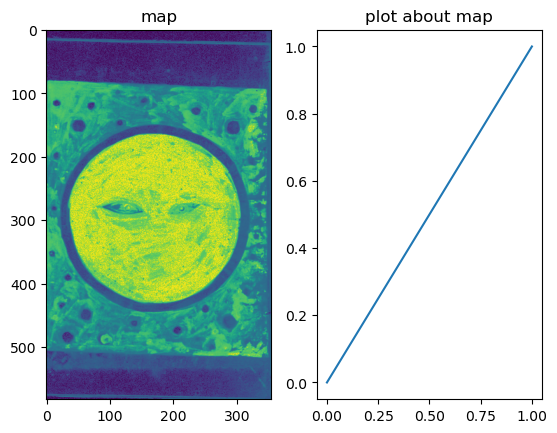

In [34]:
fig, axs = plt.subplots(ncols=2)
axs.flatten()

img = plt.imread(local_path)
axs[0].imshow(img)
axs[1].plot(range(2))

axs[0].set_title('map')
axs[1].set_title('plot about map')

In [35]:
remote_path = "falnama-project/Uploadfolder/plot.jpg"
buf = BytesIO()
fig.savefig(buf, format='jpg')
buf.seek(0)
nc.files.upload_stream(remote_path, buf)

FsNode(full_path='files/rce.kvantilburg/falnama-project/Uploadfolder/plot.jpg', file_id='00154193ocs1n7tud05d', etag='"af3c50089ba758665dd5c6e456084338"', info=FsNodeInfo(fileid=0, favorite=False, is_version=False, _last_modified=datetime.datetime(1970, 1, 1, 0, 0), _creation_date=datetime.datetime(1970, 1, 1, 0, 0), _trashbin={}), lock_info=FsNodeLockInfo())